In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
df=pd.read_csv('Mental-Health-Twitter.csv')

In [3]:
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [4]:
df.shape

(20000, 11)

In [5]:
df.columns

Index(['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id',
       'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB


In [7]:
df.isnull().sum()

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

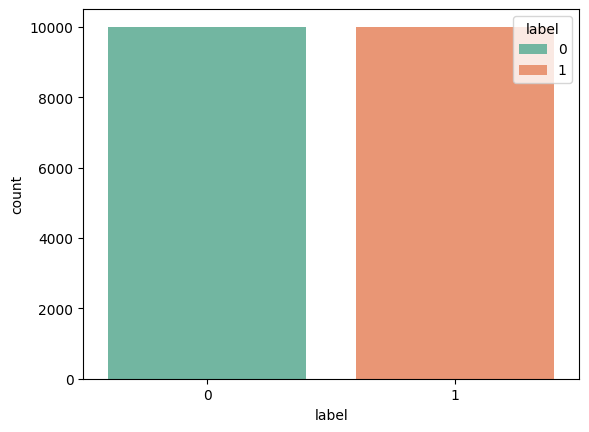

In [8]:
df['label'].value_counts()
sns.countplot(x='label',data=df, palette='Set2',hue='label')
plt.show()

- There are no missing values in the dataset
- The dataset is clean and ready for text preprocessing 
- The dataset is perfectly balanced

In [9]:
import re
def clean_text(text):
    text=text.lower()
    text=re.sub(r'https\S+|www\S+','',text)
    text = re.sub(r'@\w+', '', text)
    text=re.sub(r'[^a-z\s]','',text)
    text = re.sub(r'\s+', ' ', text).strip() 
    return text
df['cleaned_text']=df['post_text'].apply(clean_text)
df[['post_text', 'cleaned_text']].head(10)




,post_text,cleaned_text
0,It's just over 2 years since I was diagnosed w...,its just over years since i was diagnosed with...
1,"It's Sunday, I need a break, so I'm planning t...",its sunday i need a break so im planning to sp...
2,Awake but tired. I need to sleep but my brain ...,awake but tired i need to sleep but my brain h...
3,RT @SewHQ: #Retro bears make perfect gifts and...,rt retro bears make perfect gifts and are grea...
4,It’s hard to say whether packing lists are mak...,its hard to say whether packing lists are maki...
5,Making packing lists is my new hobby... #movin...,making packing lists is my new hobby movinghouse
6,At what point does keeping stuff for nostalgic...,at what point does keeping stuff for nostalgic...
7,Currently in the finding-boxes-of-random-shit ...,currently in the findingboxesofrandomshit pack...
8,"Can't be bothered to cook, take away on the wa...",cant be bothered to cook take away on the way ...
9,RT @itventsnews: ITV releases promo video for ...,rt itv releases promo video for the final seri...


In [10]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
negations={"no","not","nor","n't","never","none","nobody","nothing","nowhere","neither","hardly","scarcely","barely","doesn't","isn't","wasn't","shouldn't","wouldn't","couldn't","won't","can't","don't"}
stop_words=stop_words - negations
def remove_stopwords(text):
    words=text.split()
    filtered_words=[word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tteja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
df['final_text']=df['cleaned_text'].apply(remove_stopwords)
df[['cleaned_text','final_text']].head(10)

,cleaned_text,final_text
0,its just over years since i was diagnosed with...,years since diagnosed anxiety depression today...
1,its sunday i need a break so im planning to sp...,sunday need break im planning spend little tim...
2,awake but tired i need to sleep but my brain h...,awake tired need sleep brain ideas
3,rt retro bears make perfect gifts and are grea...,rt retro bears make perfect gifts great beginn...
4,its hard to say whether packing lists are maki...,hard say whether packing lists making life eas...
5,making packing lists is my new hobby movinghouse,making packing lists new hobby movinghouse
6,at what point does keeping stuff for nostalgic...,point keeping stuff nostalgic reasons cross li...
7,currently in the findingboxesofrandomshit pack...,currently findingboxesofrandomshit packing pha...
8,cant be bothered to cook take away on the way ...,cant bothered cook take away way lazy
9,rt itv releases promo video for the final seri...,rt itv releases promo video final series downt...


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf=TfidfVectorizer(max_features=5000,
                      min_df=5,
                      max_df=0.9,
                      ngram_range=(1,2))

In [13]:
X=Tfidf.fit_transform(df['final_text'])
y=df['label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression(solver='liblinear',max_iter=1000,random_state=42,)
model_lr.fit(X_train,y_train)
y_pred_lr=model_lr.predict(X_test)
feature_names=Tfidf.get_feature_names_out()
coefficients=model_lr.coef_[0]
top_words = sorted(
    zip(coefficients, feature_names),
    reverse=True
)
top_positive_words = top_words[:10]
print("Top 10 words indicating mental health issues:")
for coef, word in top_positive_words:
    print(f"{word}: {coef:.2f}")



Top 10 words indicating mental health issues:
depression: 6.36
addiction: 3.33
mnwild: 3.19
bbmas: 3.13
migraines: 3.07
sos: 3.00
migraine: 2.97
headache: 2.87
vegan: 2.85
autism: 2.69


In [15]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print("Logistic Regression Model")
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
print("Accuracy:",accuracy_score(y_test,y_pred_lr))

Logistic Regression Model
[[1553  447]
 [ 499 1501]]
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2000
           1       0.77      0.75      0.76      2000

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000

Accuracy: 0.7635


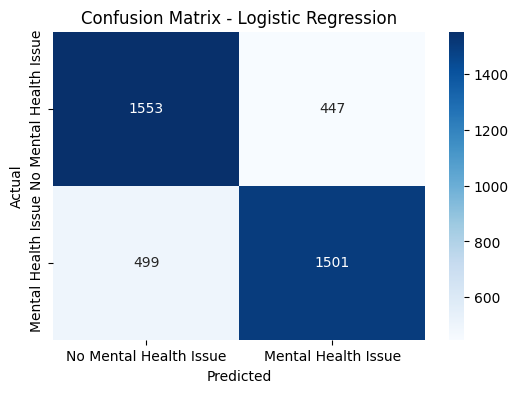

In [16]:
cm=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Mental Health Issue','Mental Health Issue'],yticklabels=['No Mental Health Issue','Mental Health Issue'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Random Forest Classifier Model
[[1590  410]
 [ 825 1175]]
              precision    recall  f1-score   support

           0       0.66      0.80      0.72      2000
           1       0.74      0.59      0.66      2000

    accuracy                           0.69      4000
   macro avg       0.70      0.69      0.69      4000
weighted avg       0.70      0.69      0.69      4000

Accuracy: 0.69125


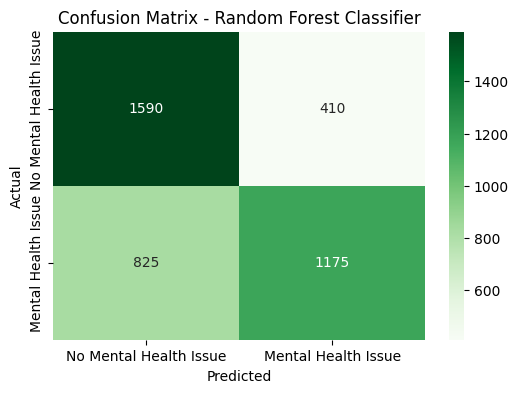

In [17]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=25,min_samples_split=5,min_samples_leaf=2,max_features='sqrt')
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
print("Random Forest Classifier Model")
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
cm_rf=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens',xticklabels=['No Mental Health Issue','Mental Health Issue'],yticklabels=['No Mental Health Issue','Mental Health Issue'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

            

In [18]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Logistic Regression metrics
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# Random Forest metrics
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

#  comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision (weighted)": [
        lr_report["weighted avg"]["precision"],
        rf_report["weighted avg"]["precision"]
    ],
    "Recall (weighted)": [
        lr_report["weighted avg"]["recall"],
        rf_report["weighted avg"]["recall"]
    ],
    "F1-score (weighted)": [
        lr_report["weighted avg"]["f1-score"],
        rf_report["weighted avg"]["f1-score"]
    ]
})

comparison_df


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.76350,0.763678,0.76350,0.76346
1,Random Forest,0.69125,0.699855,0.69125,0.68789


Among the models tested, Logistic Regression performed better than Random Forest across all evaluation metrics. It achieved an accuracy of 76.35%, while Random Forest achieved 69.12%. This is because Logistic Regression works particularly well with TF-IDF features, which are high-dimensional and sparse in nature. As a result, Logistic Regression was selected as the final model for mental health risk classification

In [19]:
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]



In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

print("ROC–AUC Score:", auc_score)


ROC–AUC Score: 0.85140825


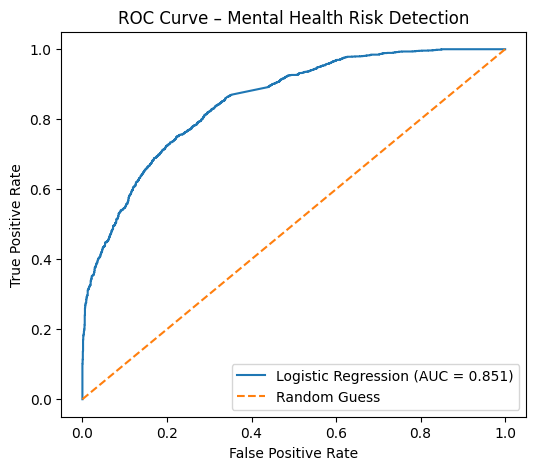

In [21]:

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Mental Health Risk Detection")
plt.legend()
plt.show()


The ROC–AUC score of 0.851 shows that the model can clearly differentiate between depressed and non-depressed text. Since the curve is far above the random baseline, the model consistently makes better decisions than random guessing

In [22]:
import joblib

joblib.dump(model_lr, "mental_health_lr_model.pkl")
joblib.dump(Tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']